In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Importing the dataset
df = pd.read_csv('/content/drive/MyDrive/Dataset/Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### **Preprocessing**

In [ ]:
df.shape

(10000, 14)

In [ ]:
X =df.drop(columns=['Exited'])
y =df.Exited

In [ ]:
print(X.Geography.unique())
print(X.Gender.unique())

['France' 'Spain' 'Germany']
['Female' 'Male']


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X.Geography=le.fit_transform(X.Geography)
X.Gender=le.fit_transform(X.Gender)

In [ ]:
X.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [ ]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10


In [ ]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


In [ ]:
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [ ]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
# Importing the Keras libraries and packages
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LeakyReLU,PReLU,ELU
from keras.layers import Dropout

### **Single Layer Neural Network**

In [ ]:
# initializing ann
single_nn = Sequential()
#  Adding input Layer and output Layer
single_nn.add(Dense(units=1,
                    kernel_initializer='glorot_uniform',
                    activation='sigmoid',
                    input_dim =10))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compiling the ANN
single_nn.compile(optimizer = 'Adam',
                  loss = 'binary_crossentropy',
                  metrics = ['accuracy'])

# Fitting the ANN to the Training set
model_history=single_nn.fit(X_train, y_train,
                            validation_split=0.33,
                            batch_size = 10,
                            epochs = 50)


Epoch 1/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5570 - loss: 0.7851 - val_accuracy: 0.6789 - val_loss: 0.6091
Epoch 2/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7115 - loss: 0.5813 - val_accuracy: 0.7762 - val_loss: 0.5061
Epoch 3/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7972 - loss: 0.4851 - val_accuracy: 0.7986 - val_loss: 0.4685
Epoch 4/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7989 - loss: 0.4606 - val_accuracy: 0.8023 - val_loss: 0.4544
Epoch 5/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8091 - loss: 0.4425 - val_accuracy: 0.8027 - val_loss: 0.4489
Epoch 6/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8184 - loss: 0.4260 - val_accuracy: 0.8027 - val_loss: 0.4468
Epoch 7/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8016 - loss: 0.4437 - val_accuracy: 0.8020 - val_loss: 0.4458
Epoch 8/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8093 - loss: 0.4341 - val_accuracy: 0.

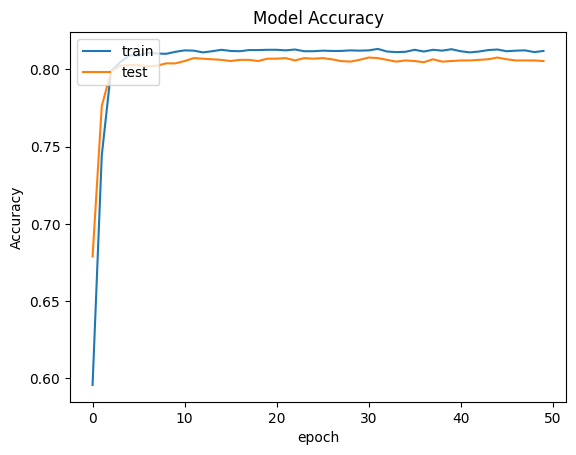

In [ ]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("epoch")
plt.legend(['train','test'],loc='upper left')
plt.show()

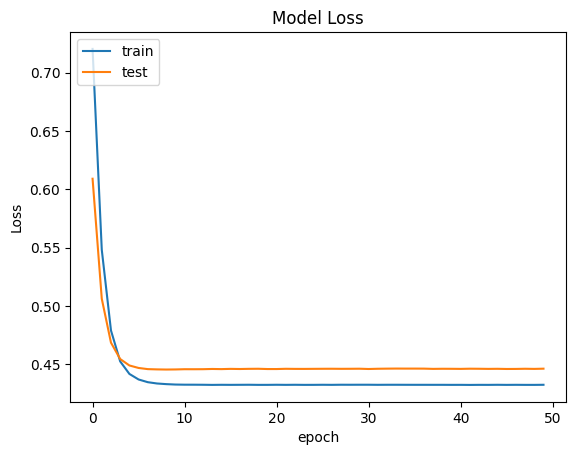

In [ ]:
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("epoch")
plt.legend(['train','test'],loc='upper left')
plt.show()

In [ ]:
# prediction
y_pred = single_nn.predict(X_test)
y_pred = (y_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# Evaluation of Models
from sklearn.metrics import confusion_matrix ,accuracy_score,classification_report
print(confusion_matrix(y_test , y_pred),"\n\n")
print("Accuracy : ", accuracy_score(y_test , y_pred),"\n\n")
print(classification_report(y_test , y_pred))

[[1539   56]
 [ 331   74]] 


Accuracy :  0.8065 


              precision    recall  f1-score   support

           0       0.82      0.96      0.89      1595
           1       0.57      0.18      0.28       405

    accuracy                           0.81      2000
   macro avg       0.70      0.57      0.58      2000
weighted avg       0.77      0.81      0.76      2000



### **Multi Layer Neural Network**

In [ ]:
# initializing
multi_nn = Sequential()
# adding input Layer and 1st hidden Layer
multi_nn.add(Dense(units = 6,
                kernel_initializer='he_uniform',
                activation='relu',
                input_dim = 10))
# adding hidden Layer2
multi_nn.add(Dense(units=6,
                   kernel_initializer='he_uniform',
                   activation='relu'))
# adding output Layer
multi_nn.add(Dense(units=1,
                   kernel_initializer='glorot_uniform',
                   activation='sigmoid'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# compiling
multi_nn.compile(optimizer='Adamax',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])
# Training
model_history=multi_nn.fit(X_train, y_train,
                            validation_split=0.33,
                            batch_size = 10,
                            epochs = 50)

Epoch 1/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6042 - loss: 0.6656 - val_accuracy: 0.7906 - val_loss: 0.5104
Epoch 2/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7911 - loss: 0.4993 - val_accuracy: 0.7955 - val_loss: 0.4863
Epoch 3/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7903 - loss: 0.4817 - val_accuracy: 0.7955 - val_loss: 0.4764
Epoch 4/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7956 - loss: 0.4667 - val_accuracy: 0.7959 - val_loss: 0.4692
Epoch 5/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7965 - loss: 0.4627 - val_accuracy: 0.7959 - val_loss: 0.4634
Epoch 6/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7975 - loss: 0.4547 - val_accuracy: 0.7986 - val_loss: 0.4585
Epoch 7/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8014 - loss: 0.4486 - val_accuracy: 0.8016 - val_loss: 0.4544
Epoch 8/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7984 - loss: 0.4495 - val_accuracy: 0.

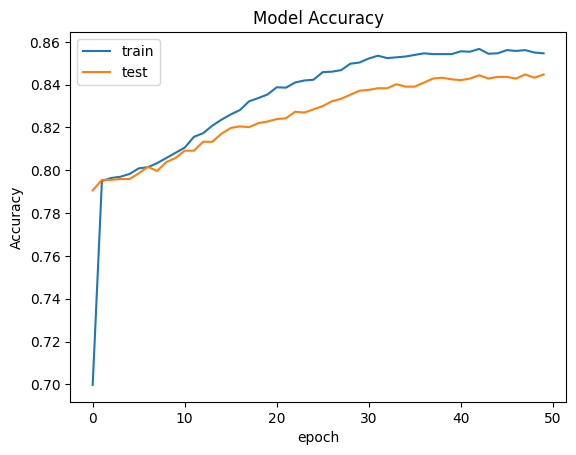

In [ ]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("epoch")
plt.legend(['train','test'],loc='upper left')
plt.show()

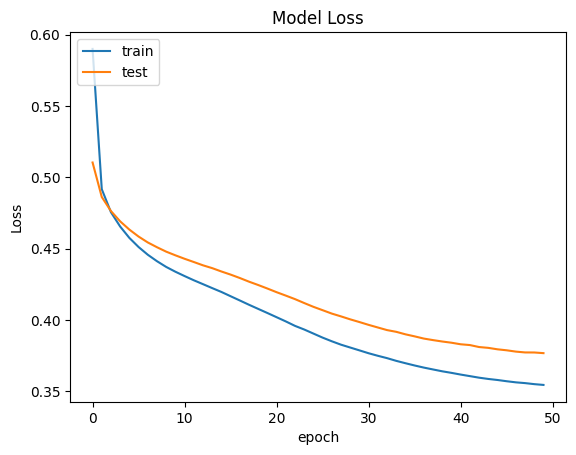

In [ ]:
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("epoch")
plt.legend(['train','test'],loc='upper left')
plt.show()

In [ ]:
# prediction
y_pred = multi_nn.predict(X_test)
y_pred = (y_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# Evaluation of models
from sklearn.metrics import confusion_matrix ,accuracy_score,classification_report
print(confusion_matrix(y_test , y_pred),"\n\n")
print("Accuracy : ", accuracy_score(y_test , y_pred),"\n\n")
print(classification_report(y_test , y_pred))

[[1516   79]
 [ 211  194]] 


Accuracy :  0.855 


              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1595
           1       0.71      0.48      0.57       405

    accuracy                           0.85      2000
   macro avg       0.79      0.71      0.74      2000
weighted avg       0.84      0.85      0.84      2000

